# Matplotlib Style Sheets

Matplotlib allows you to use different visual styles and settings. Learning how to set your own style is important if you want to be consistent throughout your graphic production. It also allows you to create output that require different specifications. So the same results may be adapted differently if you are going to do a powerpoint presentation (remember colors become bleached), you are creating a poster, a journal article or a book. Besides, it also allows you to be creative!!!

Matplotlib gives you three levels of customization, each with a different scope and priority:

1. **Setting rcParams at runtime** : changes apply immediately and persist for the rest of your session.
2. **Using style sheets**: a named bundle of rcParams you can activate with one line.
3. **Changing your `matplotlibrc` file**: the base configuration file loaded at startup.

The precedence flows from top to bottom: **rcParams at runtime > style sheets > matplotlibrc**. This means anything you set directly via `rcParams` will always win, regardless of what a style sheet says.

### Preliminary

You will want to install the following using `uv`,
```python
> uv pip install pyqt5
```

## The `matplotlibrc` File

The `matplotlibrc` file is Matplotlib's master configuration file. Every rcParam, from figure size to font family to backend, has a default value defined there. Understanding where it lives is useful both for permanent customization and for debugging unexpected styling behaviour.

### Finding the active `matplotlibrc` file

In [1]:
import matplotlib as mpl
from pathlib import Path

In [4]:
# The matplotlibrc file currently being used
mpl_style_fn= Path(mpl.matplotlib_fname())
mpl_style_fn

PosixPath('/Users/evijonas/python/archyviz/lib/python3.14/site-packages/matplotlib/mpl-data/matplotlibrc')

In [6]:
# The directory where a user-level matplotlibrc can be placed
mpl_dir= Path(mpl.get_configdir())
mpl_dir

PosixPath('/Users/evijonas/.matplotlib')

Matplotlib resolves the config file in this order:

1. The path in the `MATPLOTLIBRC` environment variable (if set).
2. A `matplotlibrc` file in the current working directory.
3. A `matplotlibrc` in your user config directory (`~/.config/matplotlib/` on Linux/Mac).
4. The library's own default file inside the Matplotlib installation.

### Generating a template to edit

The easiest way to create a user-level `matplotlibrc` is to copy the library's default file into your config directory and edit it from there.

**To do this manually:**

1. First, find the library's default file location by running `matplotlib.matplotlib_fname()` — this prints the full path.
2. Navigate to that path in your file manager or terminal and copy the file.
3. Find your user config directory by running `matplotlib.get_configdir()` — this is where your personal copy should live.
4. Paste the file there, keeping the name `matplotlibrc` (no extension).
5. Open it in any text editor. Every parameter is present but commented out with `#` — simply uncomment and change the lines you care about.
6. Save the file. **Changes take effect the next time Matplotlib is imported.**

If you prefer to do this from within a notebook, Python's `pathlib` module can handle the copy for you:


In [8]:
# Set destination 
dst = mpl_dir / "matplotlibrc"  # your user config dir

# Copy the source file to the destination
dst.write_text(mpl_style_fn.read_text())

43413

## *Matplotlib* Backends

Before diving into styles, it is worth knowing about **backends**, because they control how and where Matplotlib renders your figures. A backend is the engine that translates your plot commands into actual pixels or vector graphics.

Matplotlib backends split into two families:

- **Interactive backends** open a live GUI window (e.g. `TkAgg`, `Qt5Agg`, `MacOSX`, `WXAgg`). They allow you to pan, zoom, and resize the figure.
- **Non-interactive (hardcopy) backends** write directly to a file without showing a window (e.g. `Agg` for PNG/JPEG, `SVG`, `PDF`, `PS`).  Basically you are generating the image directly. We don't care much about these as we are usually only interested in saving our chart after it is plotted.

### Checking and changing the backend


In [9]:
import matplotlib.pyplot as plt

# Check the current backend
mpl.get_backend()   # e.g. 'TkAgg', 'module://ipykernel.pylab.backend_inline'

'module://matplotlib_inline.backend_inline'

`matplotlib_inline.backend_inline` is a module in Matplotlib specifically designed for Jupyter environments, enabling the inline display of plots directly within Jupyter notebooks.

To change the backend, you **must do so before** importing `pyplot`:

```python
import matplotlib
matplotlib.use("Agg")        # switch to non-interactive PNG renderer

import matplotlib.pyplot as plt   # now uses Agg
```

In a Jupyter notebook the backend is typically set via the `%matplotlib` magic:


In [10]:
# change backend
mpl.use('Qt5Agg')

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize= (8,8))
ax.plot([-2, 3, 1], [-1,2,0], '-ro', lw= 2)
plt.show()

2026-02-23 10:48:41.219 python3[79609:10678139] +[IMKClient subclass]: chose IMKClient_Modern
2026-02-23 10:48:41.219 python3[79609:10678139] +[IMKInputSession subclass]: chose IMKInputSession_Modern


The backend can also be set permanently in your `matplotlibrc` file:

```ini
# matplotlibrc
backend : Qt5Agg
```
There are several ways to reset the backend to work within the notebook. Type onto a code cell,

```
%matplotlib inline
```

OR

```python
matplotlib.use('module://matplotlib_inline.backend_inline')
```

## Style Sheets

Matplotlib ships with a healthy collection of built-in styles. You can see all of them at any time:

In [11]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

### Setting a Style at Runtime

To apply a style globally for your entire script or notebook session, call `plt.style.use()` before creating any figures. All subsequent plots will use that style.

```{note}
`plt.style.use()` is persistent — it stays active for the rest of the session unless you explicitly switch styles or reset with `plt.style.use("default")`.
```


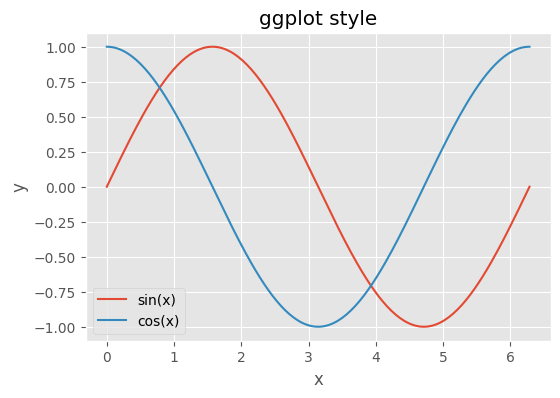

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# data
x = np.linspace(0, 2 * np.pi, 200)

# change styles
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, np.sin(x), label="sin(x)")
ax.plot(x, np.cos(x), label="cos(x)")
ax.set_title("ggplot style")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()


### Using a Style via a Context Manager

If you only want a style to apply to a specific block of code, without affecting anything else,  use `plt.style.context()` as a context manager. The style is automatically rolled back when the block exits.


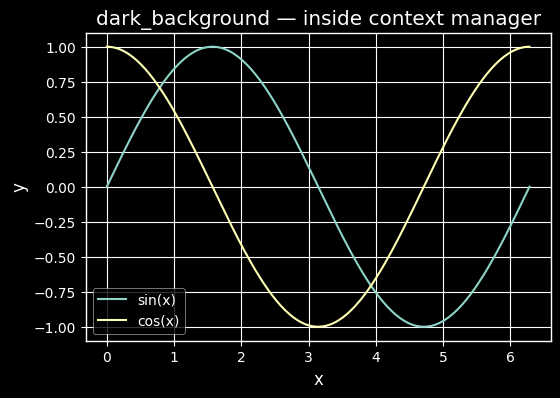

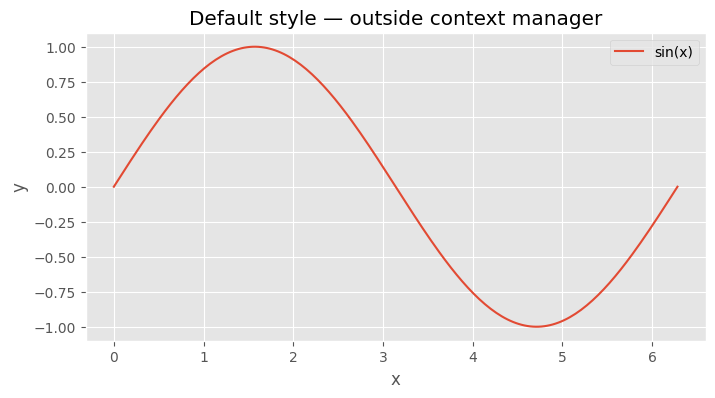

In [14]:
#Data
x = np.linspace(0, 2 * np.pi, 200)

# USE context manager
with plt.style.context('dark_background'):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(x, np.sin(x), label="sin(x)")
    ax.plot(x, np.cos(x), label="cos(x)")
    ax.set_title("dark_background — inside context manager")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    plt.show()

# Back to whatever style was active before
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, np.sin(x), label="sin(x)")
ax.set_title("Default style — outside context manager")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()


You can also **stack multiple styles** by passing a list. Later styles in the list take precedence over earlier ones:


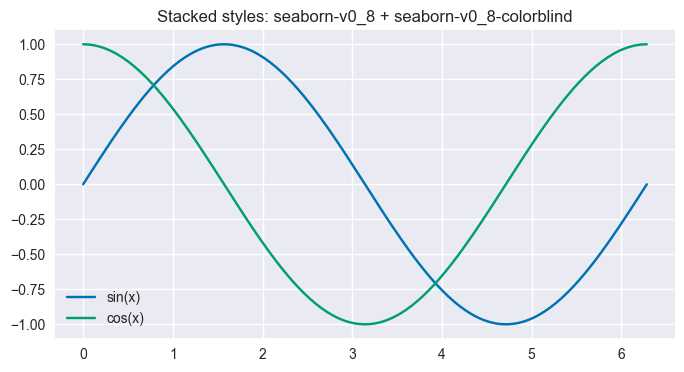

In [15]:
with plt.style.context(["seaborn-v0_8", "seaborn-v0_8-colorblind"]):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, np.sin(x), label="sin(x)")
    ax.plot(x, np.cos(x), label="cos(x)")
    ax.set_title("Stacked styles: seaborn-v0_8 + seaborn-v0_8-colorblind")
    ax.legend()
    plt.show()

Here we compare four popular styles, each applied via a context manager to the same data. 

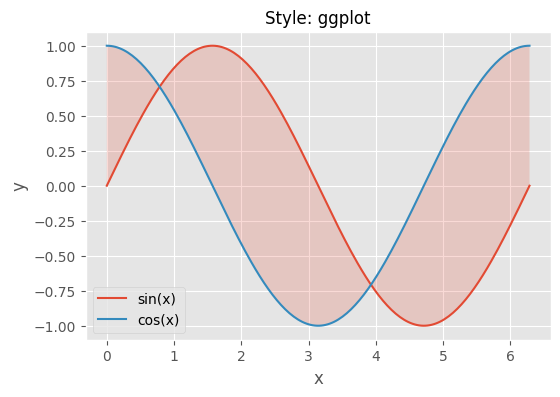

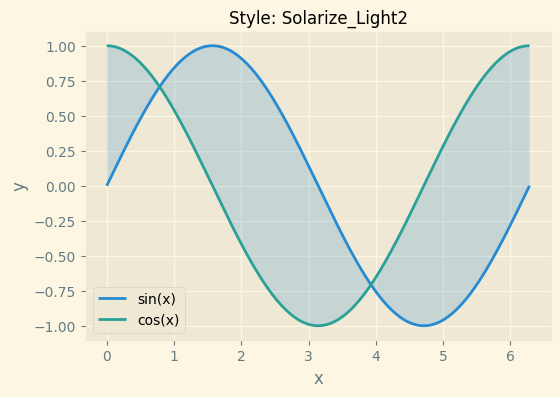

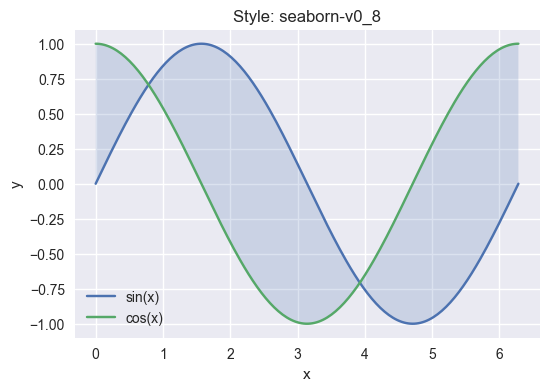

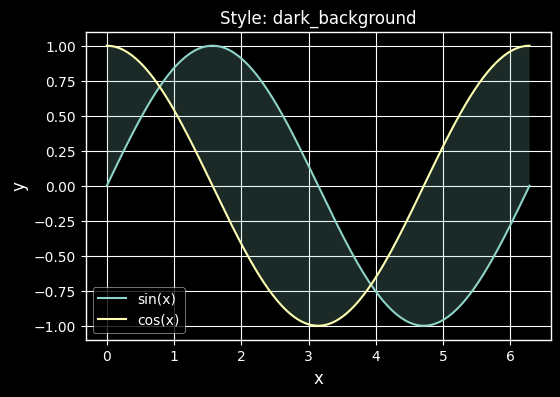

In [19]:
x = np.linspace(0, 2 * np.pi, 200)
styles = ["ggplot", "Solarize_Light2", 'seaborn-v0_8', 'dark_background']

for style in styles:
   with plt.style.context(style):
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(x, np.sin(x), label="sin(x)")
        ax.plot(x, np.cos(x), label="cos(x)")
        ax.fill_between(x, np.sin(x), np.cos(x), alpha=0.2)
        ax.set_title(f"Style: {style}", size= 12)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend()
        plt.show()

Even inside a style context, you can override individual settings via `plt.rcParams`. This is useful when a style is almost right but needs a small tweak.

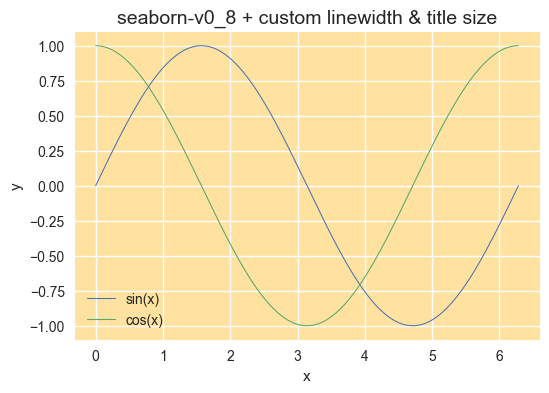

In [21]:
x = np.linspace(0, 2 * np.pi, 200)

with plt.style.context("seaborn-v0_8"):
    # change settings
    plt.rcParams["lines.linewidth"] = 0.75
    plt.rcParams["axes.titlesize"] = 14
    plt.rcParams["axes.facecolor"] = 'FFE1A0'

    # plot
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(x, np.sin(x), label="sin(x)")
    ax.plot(x, np.cos(x), label="cos(x)")
    ax.set_title("seaborn-v0_8 + custom linewidth & title size")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    plt.show()


For broader runtime overrides, use `plt.rcParams.update()` with a dictionary:

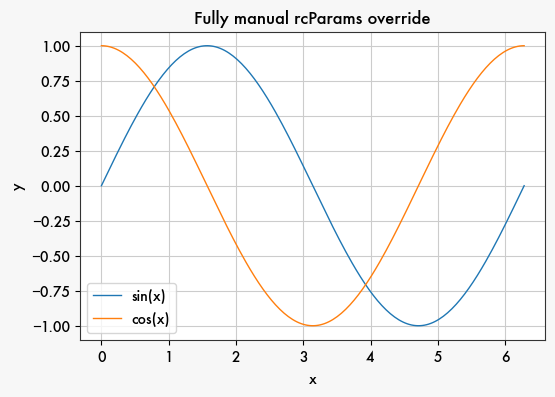

In [23]:
import numpy as np
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "f7f7f7",
    "axes.facecolor":   "ffffff",
    "axes.edgecolor":   "333333",
    "axes.grid":        True,
    "grid.color":       "cccccc",
    "lines.linewidth":  1.0,
    "font.family":      "futura",
})

x = np.linspace(0, 2 * np.pi, 200)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, np.sin(x), label="sin(x)")
ax.plot(x, np.cos(x), label="cos(x)")
ax.set_title("Fully manual rcParams override")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()


## Creating Your Own Style Sheet

A custom style sheet is a plain-text file with the `.mplstyle` extension. Each non-comment line is a `key: value` pair drawn from the full list of rcParams.

**Example style file:** `my_style.mplstyle`

```ini
figure.figsize      : 8, 5
figure.facecolor    : white
figure.dpi          : 120

axes.facecolor      : FFEDBF
axes.edgecolor      : 333333
axes.linewidth      : 1.2
axes.grid           : True
axes.titlesize      : 14
axes.titleweight    : bold
axes.labelsize      : 12
axes.labelcolor     : 333333
axes.prop_cycle     : cycler('color', ['1f77b4', 'ff7f0e', '2ca02c', 'd62728', '9467bd'])

grid.color          : cccccc
grid.linestyle      : --
grid.linewidth      : 0.8
grid.alpha          : 0.7

lines.linewidth     : 2.0
lines.markersize    : 6

xtick.direction     : in
ytick.direction     : out
xtick.labelsize     : 10
ytick.labelsize     : 10
xtick.color         : 333333
ytick.color         : 333333

legend.frameon      : True
legend.framealpha   : 0.9
legend.fontsize     : 10
legend.edgecolor    : cccccc

font.family         : sans-serif
font.sans-serif     : Calibri, DejaVu Sans
```
**Create the `stylelib` folder if it does not already exist.** Once the file is saved there, Matplotlib will detect it automatically.

In [42]:
# remember matplotlib configuration dir?
mpl_dir

PosixPath('/Users/evijonas/.matplotlib')

In [43]:
# make directory
new_pth = mpl_dir / 'stylelib'
new_pth.mkdir(exist_ok=True)

In [44]:
%pwd

'/Users/evijonas/python/archyviz/notebooks'

In [45]:
# Set destination 
dst = new_pth / 'my_style.mplstyle'  # your user config dir
src= Path('my_style.mplstyle')

# Copy the source file to the destination
dst.write_text(src.read_text())

1074

In [49]:
plt.style.reload_library()
"my_style" in plt.style.available  # True

True

Use your own style

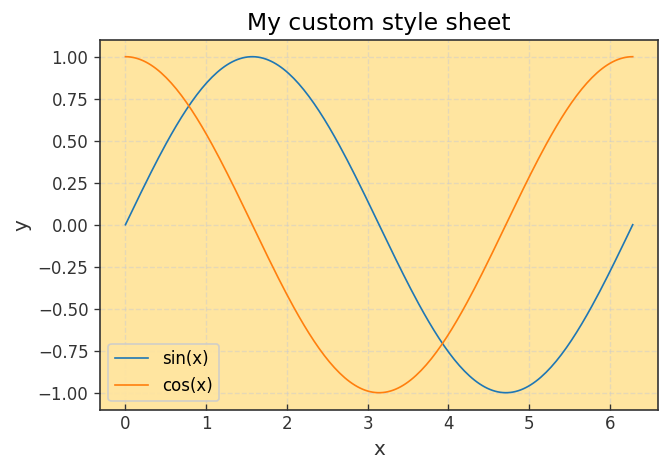

In [50]:
# data
x = np.linspace(0, 2 * np.pi, 200)

# select my stylesheet
plt.style.use('my_style')

fig, ax = plt.subplots(figsize= (6,4))
ax.plot(x, np.sin(x), label="sin(x)")
ax.plot(x, np.cos(x), label="cos(x)")
ax.set_title("My custom style sheet")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

Or combine it with a built-in style, where `my_style` overrides any conflicts:

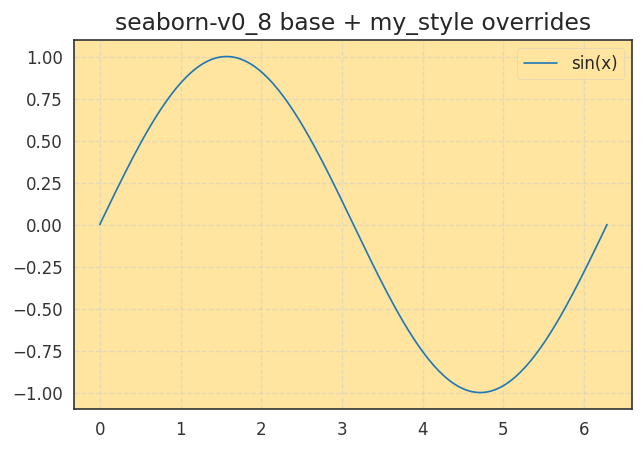

In [51]:
with plt.style.context(["seaborn-v0_8", "my_style"]):
    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(x, np.sin(x), label="sin(x)")
    ax.set_title("seaborn-v0_8 base + my_style overrides")
    ax.legend()
    plt.show()


In [36]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']